In [12]:
from virtual_accelerator.models.cu_hxr import get_cu_hxr_bmad_model
import matplotlib.pyplot as plt

In [13]:
model = get_cu_hxr_bmad_model()

# set tracking mode
model.set({"track_type": 1})

/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/bmad/variables.py:69: UserWarning: Element BEGINNING not found in device mapping
  warnings.warn(f"Element {element_name} not found in device mapping")
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:135: UserWarning: No variable configuration found for element type 'Instrument'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:135: UserWarning: No variable configuration found for element type 'Multipole'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/utils/variables.py:135: UserWarning: No variable configuration found for element type 'Monitor'
  warnings.warn(
/mnt/c/Users/Ryan Roussel/Documents/GitHub/virtual-accelerator/virtual_accelerator/bmad/variables.py:69: UserWarning: Element L0A not found in device mapping
  warnings.war

## Testing getting and setting control model variables 

In [14]:
# Get variables objects
vars = list(model.supported_variables.keys())
len(model.supported_variables.keys())

2890

In [15]:
model.get(vars)

{'SOLN:IN20:111:BCTRL': 0.0,
 'SOLN:IN20:121:BCTRL': 0.0,
 'YCOR:IN20:122:BCTRL': 0.0,
 'XCOR:IN20:121:BCTRL': 0.0,
 'XCOR:IN20:221:BCTRL': 0.0,
 'YCOR:IN20:222:BCTRL': 0.0,
 'SOLN:IN20:311:BCTRL': 0.0,
 'YCOR:IN20:312:BCTRL': 0.0,
 'XCOR:IN20:311:BCTRL': 0.0,
 'YCOR:IN20:342:BCTRL': 0.0,
 'XCOR:IN20:341:BCTRL': 0.0,
 'QUAD:IN20:361:BCTRL': -2.852256611508512,
 'QUAD:IN20:371:BCTRL': 3.168729680265059,
 'YCOR:IN20:382:BCTRL': 0.0,
 'XCOR:IN20:381:BCTRL': 0.0,
 'YCOR:IN20:412:BCTRL': 0.0,
 'XCOR:IN20:411:BCTRL': 0.0,
 'QUAD:IN20:425:BCTRL': -3.192787612737999,
 'QUAD:IN20:441:BCTRL': 2.606150267670783,
 'YCOR:IN20:492:BCTRL': 0.0,
 'XCOR:IN20:491:BCTRL': 0.0,
 'QUAD:IN20:511:BCTRL': 2.9441298727315512,
 'XCOR:IN20:521:BCTRL': 0.0,
 'YCOR:IN20:522:BCTRL': 0.0,
 'QUAD:IN20:525:BCTRL': -2.5455025806109264,
 'QUAD:IN20:631:BCTRL': 7.335358881640616,
 'XCOR:IN20:641:BCTRL': 0.0,
 'YCOR:IN20:642:BCTRL': 0.0,
 'QUAD:IN20:651:BCTRL': -5.821093449409309,
 'XCOR:IN20:721:BCTRL': 0.0,
 'YCOR:IN20:

In [16]:
# Get variable values
model.get(["OTR4_beam"])

{'OTR4_beam': <ParticleGroup with 2000 particles at 0x7f970547af10>}

In [17]:
# get rmat of QE04#1
info = model.get(["mat6", "name"])
names = info["name"]
mat6 = info["mat6"].reshape(-1, 6, 6)
mat6[list(names).index("QE04#1")]

array([[ 1.00764099e+00,  5.41374679e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.06873295e-19],
       [ 2.83359496e-01,  1.00764099e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.51329471e-20],
       [ 0.00000000e+00,  0.00000000e+00,  9.92378422e-01,
         5.38627418e-02,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -2.81921559e-01,
         9.92378422e-01,  0.00000000e+00,  0.00000000e+00],
       [ 1.50349853e-20,  1.06870654e-19,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  7.73688674e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

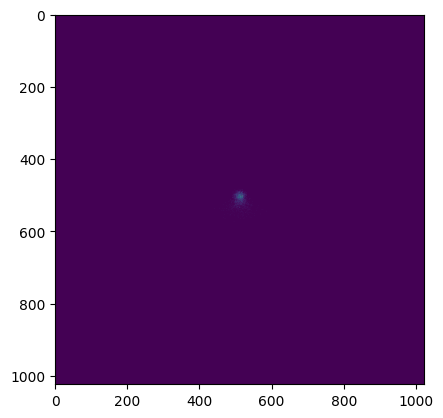

In [18]:
# get beam distribution on OTR screen
info = model.get(
    [
        "OTRS:IN20:711:Image:ArrayData",
    ]
)
fig, ax = plt.subplots()
ax.imshow(info["OTRS:IN20:711:Image:ArrayData"])

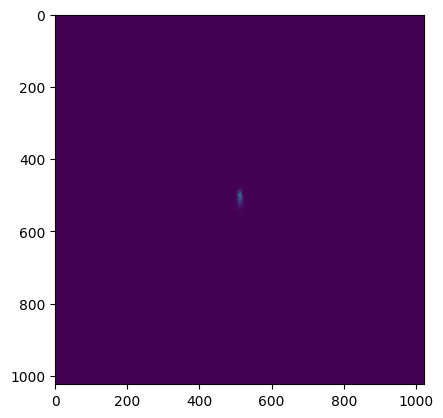

In [19]:
# change upstream quadrupole strength and see how the image changes
current_quadrupole_strength = model.get(["QUAD:IN20:631:BCTRL"])["QUAD:IN20:631:BCTRL"]
new_quadrupole_strength = current_quadrupole_strength * 0.5
model.set({"QUAD:IN20:631:BCTRL": new_quadrupole_strength})

# get beam distribution on OTR screen
info = model.get(
    [
        "OTRS:IN20:711:Image:ArrayData",
    ]
)
fig, ax = plt.subplots()
ax.imshow(info["OTRS:IN20:711:Image:ArrayData"])

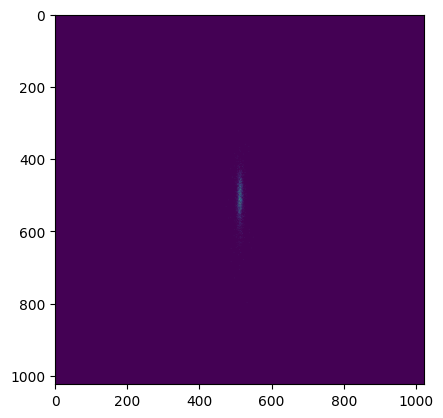

In [20]:
# change the upstream quadrupole strength directly via tao and observe the change on the OTR screen
model.tao.cmd("set ele QM01 B1_GRADIENT = 3.5")
model.update_state()

# get beam distribution on OTR screen
info = model.get(
    [
        "OTRS:IN20:711:Image:ArrayData",
    ]
)
fig, ax = plt.subplots()
ax.imshow(info["OTRS:IN20:711:Image:ArrayData"])

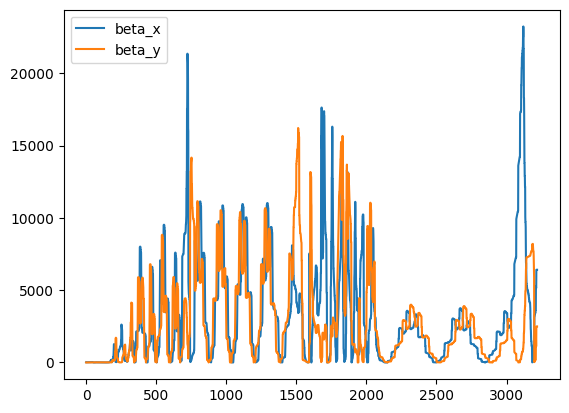

In [21]:
# plot the twiss parameters along the beamline
twiss_info = model.get(["a.beta", "b.beta"])
fig, ax = plt.subplots()
ax.plot(twiss_info["a.beta"], label="beta_x")
ax.plot(twiss_info["b.beta"], label="beta_y")
ax.legend()